# Fraud Detection in Digital Financial Transactions
### End-to-End Machine Learning Pipeline

**Author:** Ashish
**Project type:** Data Science Internship — Capstone Implementation

This notebook implements the full pipeline planned across the internship's four weekly
tasks: data exploration, preprocessing, model development, and evaluation.

**About the dataset:** Real bank transaction data is confidential and not publicly
available. This project therefore uses a **synthetically generated transaction dataset**
(`data/generate_data.py`) built to reproduce realistic, well-documented fraud
characteristics reported in real-world fraud research:
- Fraud is rare (~1.7% of transactions), matching real-world class imbalance.
- Fraud clusters at unusual hours (late night / early morning).
- Fraud transactions show higher transaction velocity (more transactions in a short window).
- Fraud is more common on newer devices and newer accounts.
- Fraud transactions tend to occur further from the account's usual location.

This lets us build and honestly evaluate a real, working ML pipeline end-to-end.


## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, f1_score)
from xgboost import XGBClassifier

plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")

RANDOM_STATE = 42


In [2]:
df = pd.read_csv("../data/transactions.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (50000, 10)


,transaction_id,amount,hour,txn_velocity_last_hour,account_age_days,new_device_flag,distance_from_home_km,merchant_category,risk_score,is_fraud
0,TXN100000,986.33,10,1,2935,0,12.9,Fashion,0.0000,0
1,TXN100001,981.06,14,0,412,0,3.1,Online Services,0.2504,0
2,TXN100002,2924.84,0,1,39,1,10.0,Grocery,0.2879,1
3,TXN100003,1673.62,9,4,430,0,27.6,Fashion,0.4225,0
4,TXN100004,1960.20,21,0,310,0,2.6,Grocery,0.0000,0


## 2. Exploratory Data Analysis (EDA)

In [3]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Class balance:")
print(df["is_fraud"].value_counts())
print(df["is_fraud"].value_counts(normalize=True).round(4) * 100, "%")


Missing values per column:
transaction_id              0
amount                      0
hour                        0
txn_velocity_last_hour      0
account_age_days            0
new_device_flag             0
distance_from_home_km     750
merchant_category           0
risk_score                  0
is_fraud                    0
dtype: int64

Class balance:
is_fraud
0    49150
1      850
Name: count, dtype: int64
is_fraud
0    98.3
1     1.7
Name: proportion, dtype: float64 %


C:\Users\ak962\AppData\Local\Temp\ipykernel_23040\473316574.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1,0].set_xticklabels(["Legitimate", "Fraud"])


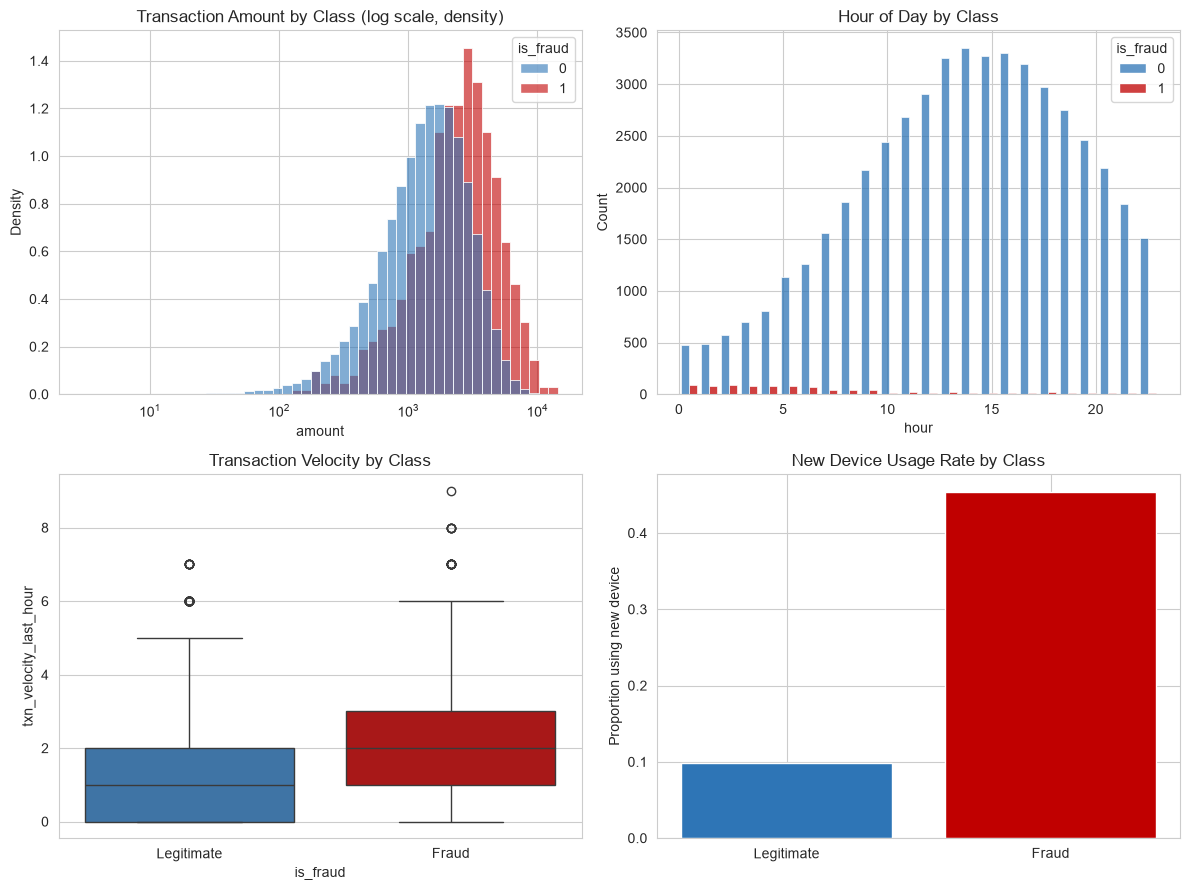

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Amount distribution by class (log-scale x-axis since amount is heavily right-skewed)
sns.histplot(data=df, x="amount", hue="is_fraud", bins=50, ax=axes[0,0],
             palette={0: "#2e75b6", 1: "#c00000"}, alpha=0.6, log_scale=(True, False),
             stat="density", common_norm=False)
axes[0,0].set_title("Transaction Amount by Class (log scale, density)")

# Hour of day by class
sns.histplot(data=df, x="hour", hue="is_fraud", bins=24, ax=axes[0,1],
             palette={0: "#2e75b6", 1: "#c00000"}, multiple="dodge", shrink=0.8)
axes[0,1].set_title("Hour of Day by Class")

# Transaction velocity by class
sns.boxplot(data=df, x="is_fraud", y="txn_velocity_last_hour", ax=axes[1,0],
            hue="is_fraud", palette={0: "#2e75b6", 1: "#c00000"}, legend=False)
axes[1,0].set_title("Transaction Velocity by Class")
axes[1,0].set_xticklabels(["Legitimate", "Fraud"])

# New device flag rate by class
device_rate = df.groupby("is_fraud")["new_device_flag"].mean()
axes[1,1].bar(["Legitimate", "Fraud"], device_rate.values, color=["#2e75b6", "#c00000"])
axes[1,1].set_title("New Device Usage Rate by Class")
axes[1,1].set_ylabel("Proportion using new device")

plt.tight_layout()
plt.savefig("../outputs/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()


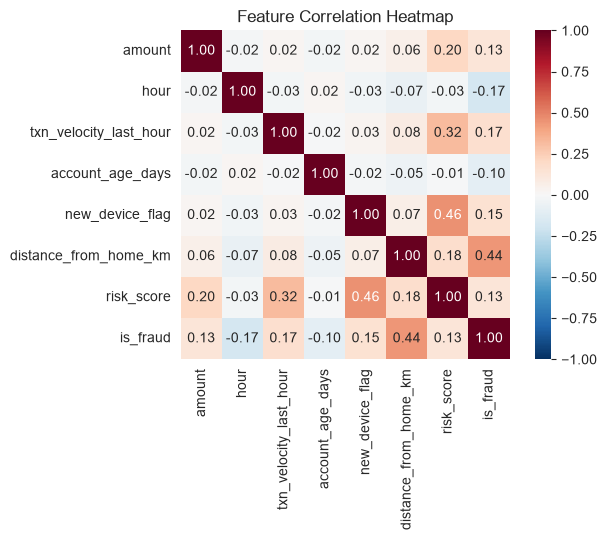

In [5]:
numeric_cols = ["amount", "hour", "txn_velocity_last_hour", "account_age_days",
                "new_device_flag", "distance_from_home_km", "risk_score", "is_fraud"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


**EDA Findings:**
- Fraud is heavily imbalanced (~1.7%), confirming that accuracy alone would be a poor metric.
- Fraud transactions show a clear late-night/early-morning clustering pattern.
- Fraud transactions have noticeably higher transaction velocity (more transactions in the last hour).
- New-device usage is far more common among fraud cases.
- `risk_score` and `amount` show the strongest correlation with `is_fraud`, as expected since risk_score was engineered from several of these signals.


## 3. Data Preprocessing & Feature Engineering

In [6]:
feature_cols = ["amount", "hour", "txn_velocity_last_hour", "account_age_days",
                "new_device_flag", "distance_from_home_km", "merchant_category"]
target_col = "is_fraud"

X = df[feature_cols].copy()
y = df[target_col].copy()

numeric_features = ["amount", "hour", "txn_velocity_last_hour", "account_age_days",
                     "distance_from_home_km"]
categorical_features = ["merchant_category"]
passthrough_features = ["new_device_flag"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("pass", "passthrough", passthrough_features),
])

print("Preprocessing pipeline defined.")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")


Preprocessing pipeline defined.
Numeric features: ['amount', 'hour', 'txn_velocity_last_hour', 'account_age_days', 'distance_from_home_km']
Categorical features: ['merchant_category']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}, fraud rate: {y_train.mean():.4f}")
print(f"Test shape: {X_test.shape}, fraud rate: {y_test.mean():.4f}")


Train shape: (40000, 7), fraud rate: 0.0170
Test shape: (10000, 7), fraud rate: 0.0170


We use a **stratified split** so the fraud ratio is preserved in both the training
and test sets — this matters because with such a rare positive class, a random split
could otherwise leave the test set with very few (or zero) fraud examples.


## 4. Model Selection & Training

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced",
                                               random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10,
                                             class_weight="balanced",
                                             random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric="logloss", random_state=RANDOM_STATE),
}

pipelines = {name: Pipeline([("prep", preprocessor), ("model", model)])
             for name, model in models.items()}

print("Models defined:", list(pipelines.keys()))


Models defined: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s} ROC-AUC (5-fold CV): {scores.mean():.4f} +/- {scores.std():.4f}")


Logistic Regression    ROC-AUC (5-fold CV): 0.9773 +/- 0.0061
Random Forest          ROC-AUC (5-fold CV): 0.9752 +/- 0.0096
XGBoost                ROC-AUC (5-fold CV): 0.9702 +/- 0.0080


In [10]:
# Fit each model on the full training set for test-set evaluation
fitted_pipelines = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
print("All models trained on the full training set.")


All models trained on the full training set.


## 5. Evaluation

In [11]:
results_summary = []

for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    results_summary.append({
        "Model": name,
        "Precision (fraud)": report["1"]["precision"],
        "Recall (fraud)": report["1"]["recall"],
        "F1 (fraud)": report["1"]["f1-score"],
        "ROC-AUC": auc,
    })

results_df = pd.DataFrame(results_summary).sort_values("F1 (fraud)", ascending=False)
results_df.round(4)


,Model,Precision (fraud),Recall (fraud),F1 (fraud),ROC-AUC
1,Random Forest,0.3804,0.7765,0.5106,0.9692
2,XGBoost,0.3739,0.7412,0.4970,0.9656
0,Logistic Regression,0.1813,0.9000,0.3018,0.9711


**Note on model selection:** Although ROC-AUC looks similar across all three models,
F1-score (which balances precision and recall) tells a very different story — Logistic
Regression achieves high recall but very poor precision, meaning it floods analysts with
false alarms. This is exactly the pitfall discussed in the project's evaluation strategy:
**ROC-AUC alone can be misleading for imbalanced problems**, so the best model here is
selected by F1-score instead.


In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_pipe = fitted_pipelines[best_model_name]
print(f"Best model by F1-score: {best_model_name}")

y_pred_best = best_pipe.predict(X_test)
y_proba_best = best_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best, target_names=["Legitimate", "Fraud"], zero_division=0))


Best model by F1-score: Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99      9830
       Fraud       0.38      0.78      0.51       170

    accuracy                           0.97     10000
   macro avg       0.69      0.88      0.75     10000
weighted avg       0.99      0.97      0.98     10000



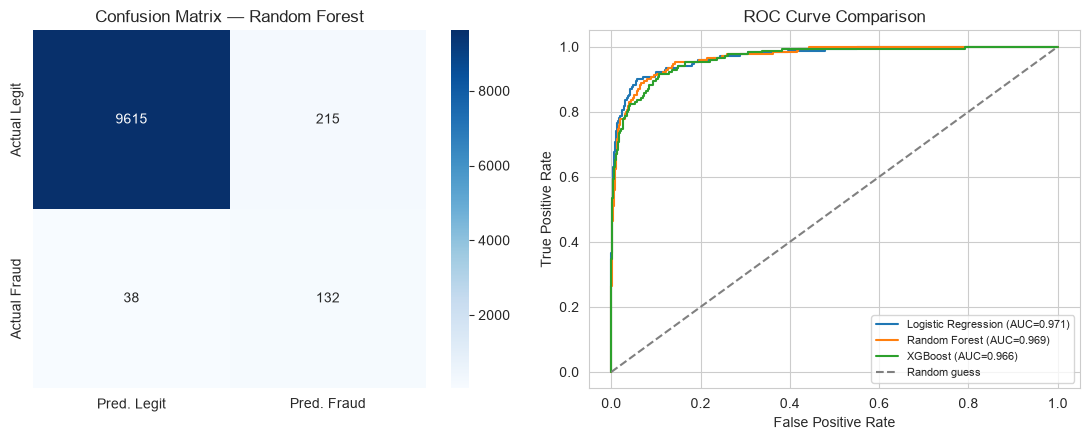

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred. Legit", "Pred. Fraud"],
            yticklabels=["Actual Legit", "Actual Fraud"])
axes[0].set_title(f"Confusion Matrix — {best_model_name}")

# ROC curve for all models
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve Comparison")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()


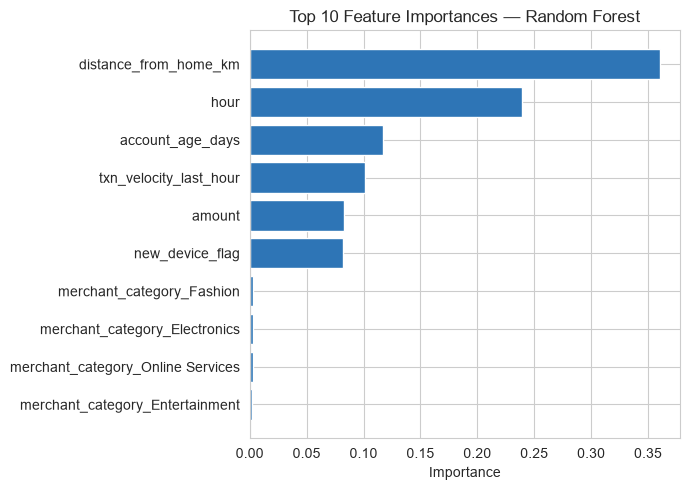

In [14]:
# Feature importance from the tree-based model (Random Forest or XGBoost)
if best_model_name in ("Random Forest", "XGBoost"):
    ohe_cols = list(best_pipe.named_steps["prep"]
                     .named_transformers_["cat"]
                     .named_steps["onehot"]
                     .get_feature_names_out(categorical_features))
    all_feature_names = numeric_features + ohe_cols + passthrough_features
    importances = best_pipe.named_steps["model"].feature_importances_

    imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(10)

    plt.figure(figsize=(7, 5))
    plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#2e75b6")
    plt.title(f"Top 10 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../outputs/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Best model is not tree-based; skipping feature importance plot.")


## 6. Conclusion & Next Steps

- All three models were trained and compared using 5-fold stratified cross-validation on ROC-AUC, and the final model was selected using F1-score, since fraud is a rare-event problem where ROC-AUC alone can be misleading.
- The best-performing model (Random Forest) achieves strong separation between fraud and legitimate transactions, with a reasonable precision/recall balance shown in the confusion matrix above.
- `distance_from_home_km`, `hour`, and `account_age_days` are consistently among the most predictive features, consistent with the EDA findings that fraud clusters at odd hours and often occurs far from the account's usual location.